# Clustering with K-Means and DBSCAN, Step by Step

No target column anywhere in this notebook. Part 1 teaches the whole method on 20 points you can check by hand. Part 2 repeats it on a real dataset, start to finish.

### Table of contents
1. [Part 1: The whole method on 20 points](#1.-Part-1:-The-whole-method-on-20-points)
2. [Part 2: Mall Customers, a real dataset start to finish](#2.-Part-2:-Mall-Customers,-a-real-dataset-start-to-finish)
3. [Exercises](#3.-Exercises)

## 1. Part 1: The whole method on 20 points

Twenty shoppers, two numbers each: annual income (in thousands) and a spending score from 1 to 100. Nobody told us which shopper belongs to which group.

In [1]:
import numpy as np
import pandas as pd

shoppers = pd.DataFrame(
    [(15, 78), (18, 85), (22, 72), (25, 80), (20, 90), (28, 76),
     (78, 82), (85, 90), (90, 75), (82, 70), (95, 85), (88, 80),
     (80, 22), (85, 15), (92, 28), (88, 10), (76, 30), (96, 20),
     (58, 40), (38, 78)],
    columns=["annual_income", "spending_score"],
)
shoppers

,annual_income,spending_score
0,15,78
1,18,85
2,22,72
3,25,80
4,20,90
5,28,76
6,78,82
7,85,90
8,90,75
9,82,70


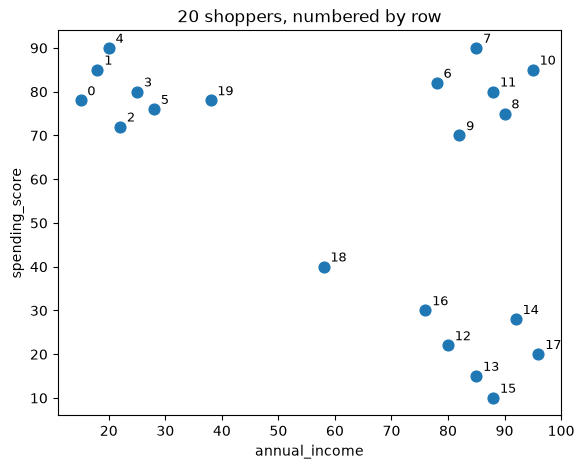

In [2]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6.5, 5))
ax.scatter(shoppers["annual_income"], shoppers["spending_score"], s=60)
for i, row in shoppers.iterrows():
    ax.annotate(str(i), (row["annual_income"] + 1.2, row["spending_score"] + 1.2), fontsize=9)
ax.set_xlabel("annual_income")
ax.set_ylabel("spending_score")
ax.set_title("20 shoppers, numbered by row")
plt.show()

How many groups do you see? Three blobs, and one shopper (number 18) who does not fit anywhere.

In [3]:
# a small helper reused for every scatter plot in this notebook; -1 is DBSCAN's label for noise
colors = np.array(["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3", "#937860"])

def plot_clusters(ax, x, y, labels, title, centers=None):
    x_name, y_name = x.name, y.name
    x, y, labels = np.asarray(x), np.asarray(y), np.asarray(labels)
    noise = labels == -1
    ax.scatter(x[noise], y[noise], c="lightgray", s=45, label="noise")
    ax.scatter(x[~noise], y[~noise], c=colors[labels[~noise] % len(colors)], s=45)
    if centers is not None:
        ax.scatter(centers[0], centers[1], marker="X", s=220, c="black", edgecolor="white")
    ax.set_xlabel(x_name)
    ax.set_ylabel(y_name)
    ax.set_title(title)

### K-Means by hand

Pick 3 starting centroids. We use three of the shoppers themselves: rows 0, 6 and 12.

In [4]:
X_tiny = shoppers.to_numpy(dtype=float)
centroids = X_tiny[[0, 6, 12]]
centroids

array([[15., 78.],
       [78., 82.],
       [80., 22.]])

**Step 1:** assign every shopper to the nearest centroid.

In [5]:
distances = np.linalg.norm(X_tiny[:, None, :] - centroids[None, :, :], axis=2)   # 20 x 3 table of distances
assignments = distances.argmin(axis=1)
print(assignments)

[0 0 0 0 0 0 1 1 1 1 1 1 2 2 2 2 2 2 2 0]


**Step 2:** move each centroid to the mean of the shoppers assigned to it.

In [6]:
new_centroids = np.array([X_tiny[assignments == c].mean(axis=0) for c in range(3)])
new_centroids.round(1)

array([[23.7, 79.9],
       [86.3, 80.3],
       [82.1, 23.6]])

Repeat both steps until nothing changes. Inertia is the sum of squared distances from every shopper to its centroid.

In [7]:
centroids = X_tiny[[0, 6, 12]]
for round_number in range(10):
    distances = np.linalg.norm(X_tiny[:, None, :] - centroids[None, :, :], axis=2)
    assignments = distances.argmin(axis=1)
    inertia = (distances.min(axis=1) ** 2).sum()
    new_centroids = np.array([X_tiny[assignments == c].mean(axis=0) for c in range(3)])
    print(f"round {round_number}: inertia = {inertia:.1f}")
    if np.allclose(new_centroids, centroids):
        break
    centroids = new_centroids

round 0: inertia = 3596.0
round 1: inertia = 2557.5


Inertia fell, then the centroids stopped moving. That is convergence, and it took two rounds. Now the same thing with `scikit-learn`:

In [8]:
from sklearn.cluster import KMeans

kmeans_tiny = KMeans(n_clusters=3, init=X_tiny[[0, 6, 12]], n_init=1)
kmeans_tiny.fit(X_tiny)

print("same groups as our loop:", np.array_equal(kmeans_tiny.labels_, assignments))
print("inertia:", round(kmeans_tiny.inertia_, 1))

same groups as our loop: True
inertia: 2557.5


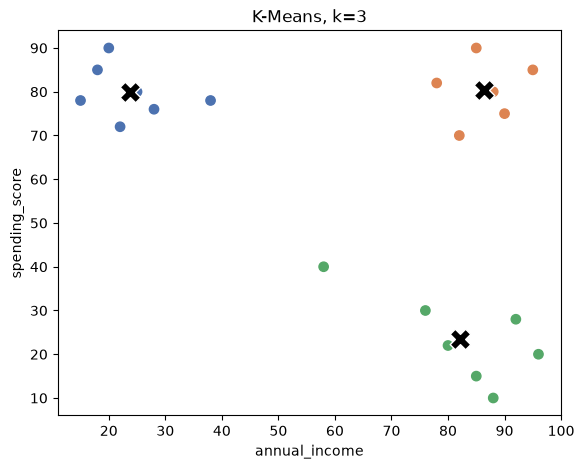

In [9]:
fig, ax = plt.subplots(figsize=(6.5, 5))
plot_clusters(ax, shoppers["annual_income"], shoppers["spending_score"], kmeans_tiny.labels_,
              "K-Means, k=3", centers=kmeans_tiny.cluster_centers_.T)
plt.show()

### Choosing k: inertia and the elbow

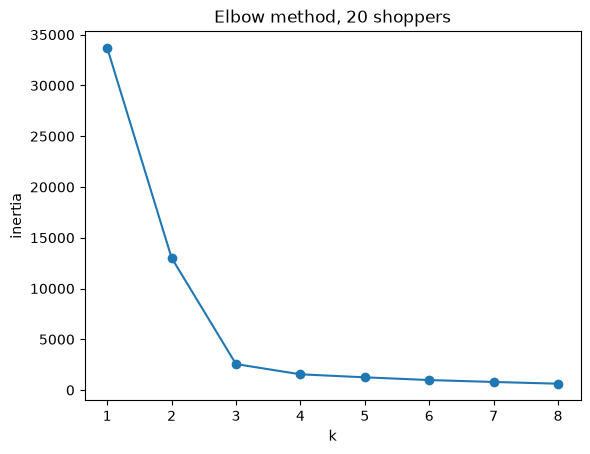

In [10]:
inertias = []
for k in range(1, 9):
    inertias.append(KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_tiny).inertia_)

plt.plot(range(1, 9), inertias, marker="o")
plt.xlabel("k")
plt.ylabel("inertia")
plt.title("Elbow method, 20 shoppers")
plt.show()

Inertia always falls as `k` grows, so the lowest value is never the answer. The bend at `k=3` is.

### Choosing k: silhouette

For every point: `a` is its average distance to its own cluster, `b` its average distance to the nearest other cluster, and the silhouette is `(b - a) / max(a, b)`. Close to 1 means clearly in the right cluster. Close to 0 means on the border.

In [11]:
def silhouette_by_hand(i, X, labels):
    dists = np.linalg.norm(X - X[i], axis=1)
    own = (labels == labels[i]) & (np.arange(len(X)) != i)
    a = dists[own].mean()
    b = min(dists[labels == c].mean() for c in set(labels) if c != labels[i])
    return (b - a) / max(a, b)

labels_tiny = kmeans_tiny.labels_
print(f"shopper 0:  {silhouette_by_hand(0, X_tiny, labels_tiny):.3f}")
print(f"shopper 18: {silhouette_by_hand(18, X_tiny, labels_tiny):.3f}")

shopper 0:  0.823
shopper 18: 0.303


A typical shopper scores high. Shopper 18, who fits nowhere, scores much lower. Confirm with `scikit-learn`, which does this for every point:

In [12]:
from sklearn.metrics import silhouette_samples, silhouette_score

per_point = silhouette_samples(X_tiny, labels_tiny)
print("shopper 0 and 18:", per_point[[0, 18]].round(3))
print("lowest three shoppers:", np.argsort(per_point)[:3])

shopper 0 and 18: [0.823 0.303]
lowest three shoppers: [18 19 16]


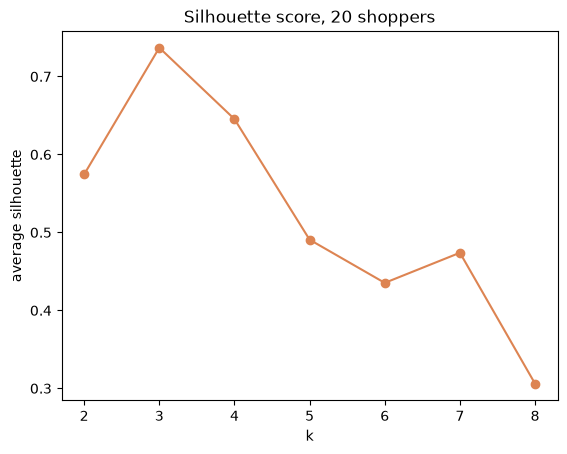

In [13]:
silhouettes = []
for k in range(2, 9):
    labels_k = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_tiny)
    silhouettes.append(silhouette_score(X_tiny, labels_k))

plt.plot(range(2, 9), silhouettes, marker="o", color="#DD8452")
plt.xlabel("k")
plt.ylabel("average silhouette")
plt.title("Silhouette score, 20 shoppers")
plt.show()

Elbow and silhouette agree: `k=3`.

### DBSCAN by hand

DBSCAN has no `k`. It needs a radius `eps` and a count `min_samples`. A point with at least `min_samples` neighbors within `eps` (itself included) is a **core** point.

In [14]:
eps = 15
min_samples = 3

D = np.linalg.norm(X_tiny[:, None, :] - X_tiny[None, :, :], axis=2)   # 20 x 20 distances
neighbor_counts = (D <= eps).sum(axis=1)
is_core = neighbor_counts >= min_samples
print("neighbors within eps:", neighbor_counts)

neighbors within eps: [6 6 5 7 4 6 5 4 5 4 4 6 5 5 4 4 2 4 1 3]


A **border** point is not core but sits within `eps` of a core point. Everything else is **noise**.

In [15]:
is_border = ~is_core & (D[:, is_core] <= eps).any(axis=1)
is_noise = ~is_core & ~is_border

point_types = np.where(is_core, "core", np.where(is_border, "border", "noise"))
pd.DataFrame({"neighbors": neighbor_counts, "type": point_types}).T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
neighbors,6,6,5,7,4,6,5,4,5,4,4,6,5,5,4,4,2,4,1,3
type,core,core,core,core,core,core,core,core,core,core,core,core,core,core,core,core,border,core,noise,core


Confirm with `scikit-learn`:

In [16]:
from sklearn.cluster import DBSCAN

dbscan_tiny = DBSCAN(eps=eps, min_samples=min_samples).fit(X_tiny)
print("labels:", dbscan_tiny.labels_)
print("core points match:", set(dbscan_tiny.core_sample_indices_) == set(np.where(is_core)[0]))

labels: [ 0  0  0  0  0  0  1  1  1  1  1  1  2  2  2  2  2  2 -1  0]
core points match: True


Clusters are labeled 0, 1, 2 and the noise point gets `-1`. The odd shopper is now flagged instead of forced into a group.

### The effect of eps

In [17]:
rows = []
for eps_value in [5, 8, 10, 12, 15, 20, 30]:
    labels_e = DBSCAN(eps=eps_value, min_samples=3).fit_predict(X_tiny)
    rows.append({
        "eps": eps_value,
        "clusters": len(set(labels_e)) - (1 if -1 in labels_e else 0),
        "noise points": int((labels_e == -1).sum()),
    })
pd.DataFrame(rows).set_index("eps")

,clusters,noise points
eps,,
5,0,20
8,2,14
10,3,6
12,3,3
15,3,1
20,3,1
30,3,0


Too small and everything is noise or fragments. From `15` to `20` it is clean. At `30` even the odd shopper gets absorbed, so the noise disappears.

### K-Means vs DBSCAN on the same 20 shoppers

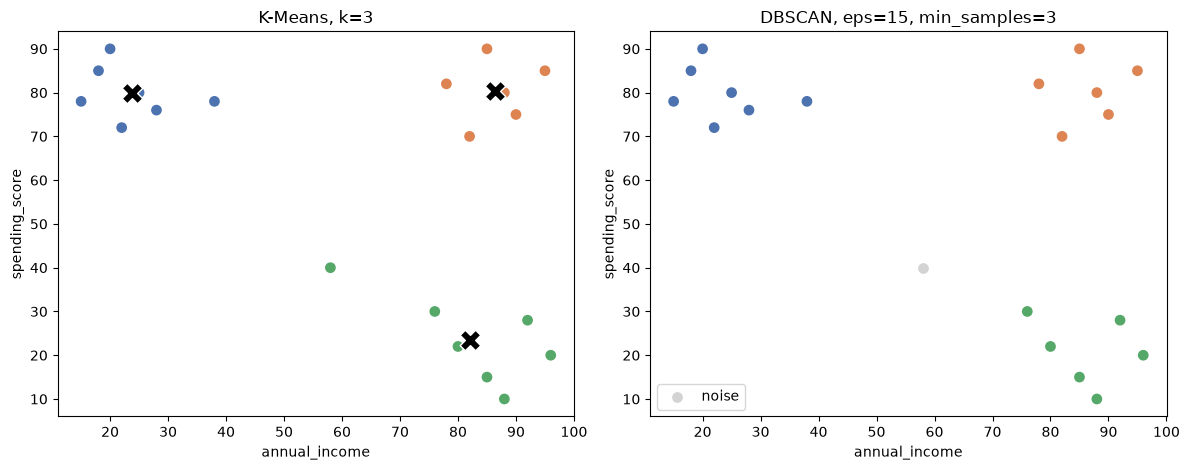

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
plot_clusters(axes[0], shoppers["annual_income"], shoppers["spending_score"], kmeans_tiny.labels_,
              "K-Means, k=3", centers=kmeans_tiny.cluster_centers_.T)
plot_clusters(axes[1], shoppers["annual_income"], shoppers["spending_score"], dbscan_tiny.labels_,
              "DBSCAN, eps=15, min_samples=3")
axes[1].legend()
plt.tight_layout()
plt.show()

Same three groups. K-Means gives shopper 18 a cluster anyway and drags a centroid toward it. DBSCAN says it belongs to none. One more thing before real data.

### One trap: units

So far both features lived on a similar 0 to 100 scale. Now write income in dollars instead of thousands. Nothing about the shoppers has changed.

In [19]:
X_dollars = X_tiny.copy()
X_dollars[:, 0] *= 1000      # income in dollars: 15,000 to 96,000

kmeans_dollars = KMeans(n_clusters=3, random_state=42, n_init=10).fit(X_dollars)
print(kmeans_dollars.labels_)

[1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 2 2]


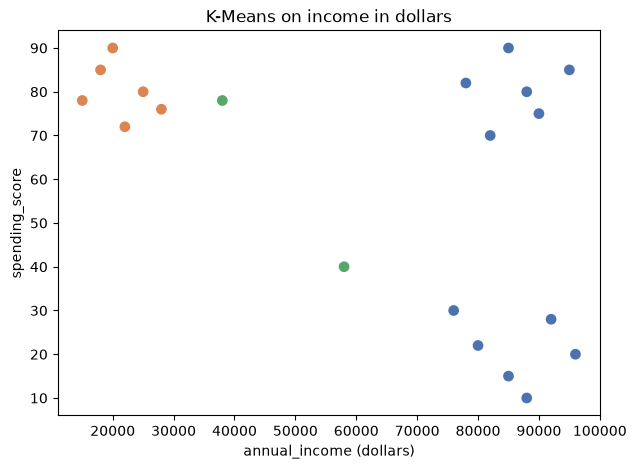

In [20]:
fig, ax = plt.subplots(figsize=(7, 5))
plot_clusters(ax, pd.Series(X_dollars[:, 0], name="annual_income (dollars)"),
              pd.Series(X_dollars[:, 1], name="spending_score"), kmeans_dollars.labels_,
              "K-Means on income in dollars")
plt.show()

Two of the three groups merged. Income is now in the tens of thousands while spending is below 100, so income decides every distance and spending is ignored.

The fix: put every feature on the same scale first. `StandardScaler` subtracts the mean and divides by the standard deviation.

In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score

X_dollars_scaled = StandardScaler().fit_transform(X_dollars)
labels_scaled = KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(X_dollars_scaled)

print("scaled labels:", labels_scaled)
print("agreement with our first K-Means (1.0 = identical groups):", adjusted_rand_score(kmeans_tiny.labels_, labels_scaled))

scaled labels: [2 2 2 2 2 2 0 0 0 0 0 0 1 1 1 1 1 1 1 2]
agreement with our first K-Means (1.0 = identical groups): 1.0


Same three groups as before, even with income in dollars. K-Means and DBSCAN both measure distance, so scale first, every time.

## 2. Part 2: Mall Customers, a real dataset start to finish

200 mall customers, no target and no answer key at all. This is the situation clustering is actually used in: a business wants customer segments.

In [22]:
mall = pd.read_csv("assets/Mall_Customers.csv")
mall.columns = ["customer_id", "gender", "age", "income", "spending"]   # shorter names
mall.head(10)

,customer_id,gender,age,income,spending
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


| Column | Meaning |
|---|---|
| `customer_id` | Row identifier, carries no information |
| `gender` | Male / Female |
| `age` | Age in years |
| `income` | Annual income, in thousands of dollars |
| `spending` | Spending score from 1 to 100, assigned by the mall |

### Exploratory data analysis

In [23]:
print("shape:", mall.shape)
print("missing values:", mall.isna().sum().sum())
print("duplicate rows:", mall.duplicated().sum())
mall[["age", "income", "spending"]].describe().round(1)

shape: (200, 5)
missing values: 0
duplicate rows: 0


,age,income,spending
count,200.0,200.0,200.0
mean,38.8,60.6,50.2
std,14.0,26.3,25.8
min,18.0,15.0,1.0
25%,28.8,41.5,34.8
50%,36.0,61.5,50.0
75%,49.0,78.0,73.0
max,70.0,137.0,99.0


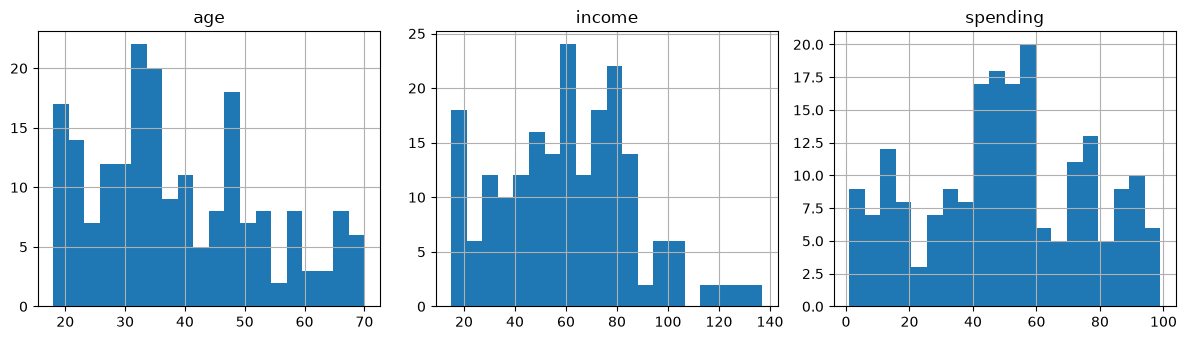

In [24]:
mall[["age", "income", "spending"]].hist(figsize=(12, 3.5), bins=20, layout=(1, 3))
plt.tight_layout()
plt.show()

In [25]:
mall["gender"].value_counts()

gender
Female    112
Male       88
Name: count, dtype: int64

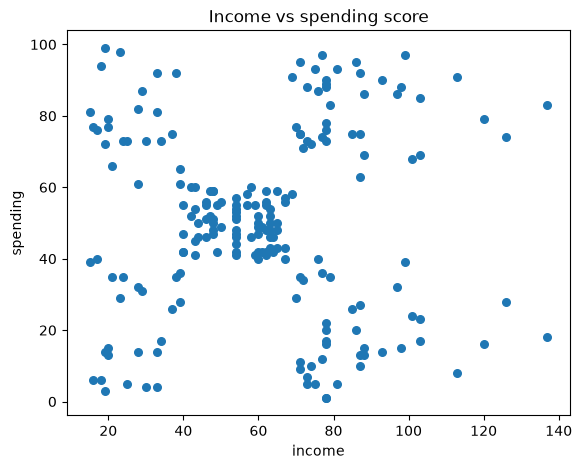

In [26]:
fig, ax = plt.subplots(figsize=(6.5, 5))
ax.scatter(mall["income"], mall["spending"], s=30)
ax.set_xlabel("income")
ax.set_ylabel("spending")
ax.set_title("Income vs spending score")
plt.show()

No labels, no colors. How many groups do you see?

### Choosing the features

We cluster on `income` and `spending`: two features we can plot, and the two a marketing team cares about. `customer_id` is just a row number, and `gender` is not numeric.

In [27]:
features_mall = ["income", "spending"]
X_mall = mall[features_mall]
scaler_mall = StandardScaler()
X_mall_scaled = scaler_mall.fit_transform(X_mall)   # both columns look alike in range, but we scale anyway

### Choosing k

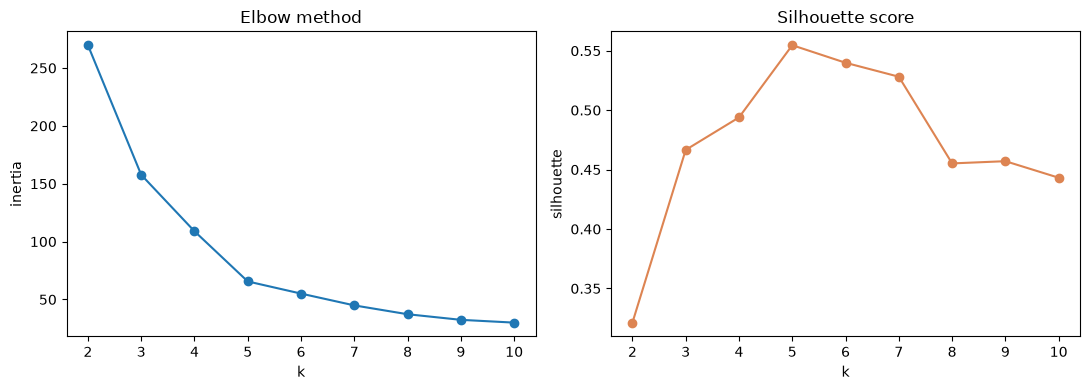

In [28]:
inertias_mall, silhouettes_mall = [], []
for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_mall_scaled)
    inertias_mall.append(model.inertia_)
    silhouettes_mall.append(silhouette_score(X_mall_scaled, model.labels_))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(range(2, 11), inertias_mall, marker="o")
axes[0].set_title("Elbow method")
axes[0].set_xlabel("k")
axes[0].set_ylabel("inertia")
axes[1].plot(range(2, 11), silhouettes_mall, marker="o", color="#DD8452")
axes[1].set_title("Silhouette score")
axes[1].set_xlabel("k")
axes[1].set_ylabel("silhouette")
plt.tight_layout()
plt.show()

Both point to `k=5`: the elbow flattens after it and silhouette peaks there.

### K-Means with k=5

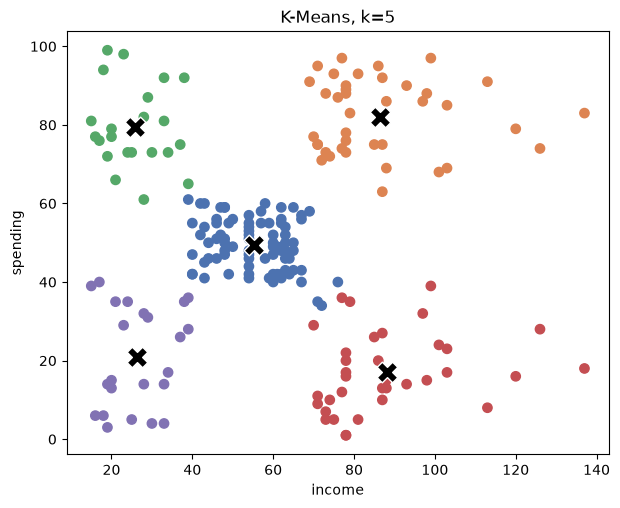

In [29]:
kmeans_mall = KMeans(n_clusters=5, random_state=42, n_init=10).fit(X_mall_scaled)
mall_centers = pd.DataFrame(scaler_mall.inverse_transform(kmeans_mall.cluster_centers_), columns=features_mall)

fig, ax = plt.subplots(figsize=(7, 5.5))
plot_clusters(ax, mall["income"], mall["spending"], kmeans_mall.labels_, "K-Means, k=5",
              centers=(mall_centers["income"], mall_centers["spending"]))
plt.show()

### What does each cluster mean?

With no answer key, meaning comes from profiling: average every column, including the ones we did not cluster on.

In [30]:
mall["cluster"] = kmeans_mall.labels_
profile = mall.groupby("cluster")[["age", "income", "spending"]].mean().round(1)
profile["customers"] = mall["cluster"].value_counts().sort_index()
profile

,age,income,spending,customers
cluster,,,,
0,42.7,55.3,49.5,81
1,32.7,86.5,82.1,39
2,25.3,25.7,79.4,22
3,41.1,88.2,17.1,35
4,45.2,26.3,20.9,23


Five recognizable segments: high income with high spending, high income with low spending, low income with high spending (younger), low income with low spending, and a large middle group. A marketer could act on each of these.

In [31]:
pd.crosstab(mall["cluster"], mall["gender"])

gender,Female,Male
cluster,,
0,48,33
1,21,18
2,13,9
3,16,19
4,14,9


Gender is spread across every segment, so it does not drive the clusters.

### Can we trust it without labels?

We cannot check against a truth, but we can check whether the result is stable: rerun with different random starts and see if the same groups come back.

In [32]:
runs = [KMeans(n_clusters=5, n_init=1, random_state=seed).fit_predict(X_mall_scaled) for seed in range(6)]
print("agreement with run 0:", [round(adjusted_rand_score(runs[0], r), 3) for r in runs[1:]])

agreement with run 0: [0.985, 1.0, 0.985, 0.692, 0.985]


Most runs agree almost perfectly, so the same customers keep landing together. The one lower value is an unlucky random start, which is why `n_init=10` keeps the best of several.

### DBSCAN on the same customers

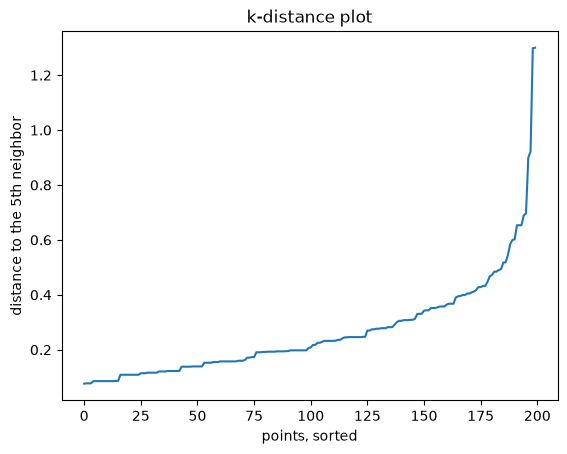

In [33]:
from sklearn.neighbors import NearestNeighbors

min_samples_mall = 5
distances_mall, _ = NearestNeighbors(n_neighbors=min_samples_mall).fit(X_mall_scaled).kneighbors(X_mall_scaled)

plt.plot(np.sort(distances_mall[:, -1]))
plt.xlabel("points, sorted")
plt.ylabel(f"distance to the {min_samples_mall}th neighbor")
plt.title("k-distance plot")
plt.show()

In [34]:
rows = []
for eps_value in [0.2, 0.3, 0.4, 0.5, 0.6]:
    labels_m = DBSCAN(eps=eps_value, min_samples=min_samples_mall).fit_predict(X_mall_scaled)
    rows.append({
        "eps": eps_value,
        "clusters": len(set(labels_m)) - (1 if -1 in labels_m else 0),
        "noise points": int((labels_m == -1).sum()),
    })
pd.DataFrame(rows).set_index("eps")

,clusters,noise points
eps,,
0.2,7,77
0.3,7,35
0.4,4,15
0.5,2,8
0.6,1,5


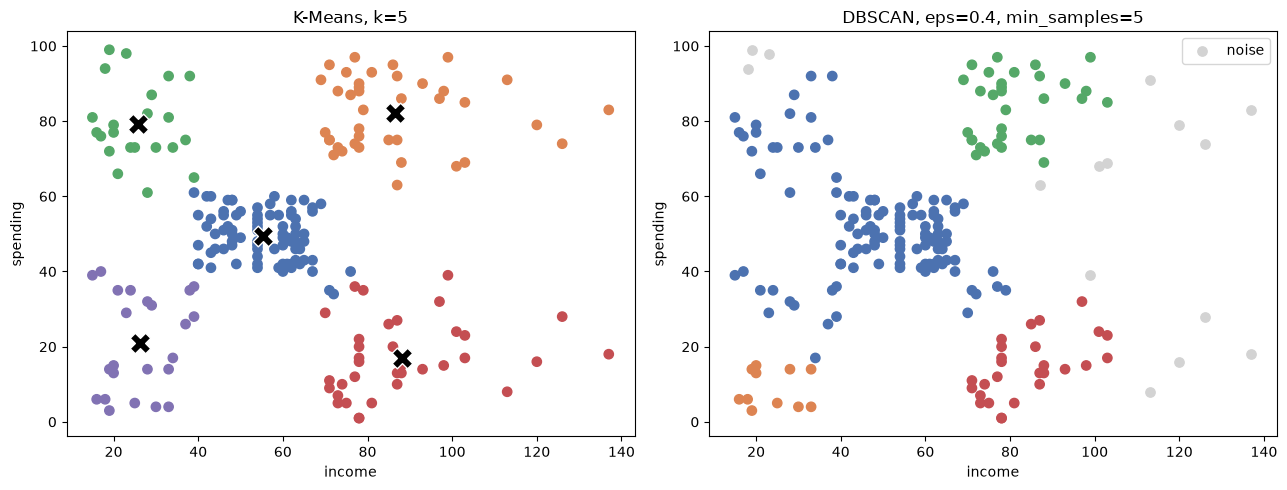

In [35]:
dbscan_mall = DBSCAN(eps=0.4, min_samples=min_samples_mall).fit(X_mall_scaled)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_clusters(axes[0], mall["income"], mall["spending"], kmeans_mall.labels_, "K-Means, k=5",
              centers=(mall_centers["income"], mall_centers["spending"]))
plot_clusters(axes[1], mall["income"], mall["spending"], dbscan_mall.labels_, "DBSCAN, eps=0.4, min_samples=5")
axes[1].legend()
plt.tight_layout()
plt.show()

DBSCAN swallows the low-income, high-spending group into the large middle group and marks the high-income fringe as noise. The segments touch each other with no empty gap between them, and DBSCAN needs a gap. K-Means is the better tool for segmentation like this.

## 3. Exercises

Pick **Wine** or **Penguins** and repeat the Mall Customers workflow on it, in your own notebook.

| Step | What to do |
|---|---|
| 1. Load | `load_wine(as_frame=True)` or `fetch_openml("penguins", version=1, as_frame=True)` |
| 2. Set aside | Keep the answer column (`target` for Wine, `species` for Penguins) out of the features, and do not look at it until step 7 |
| 3. EDA | Shape, missing values, duplicates, ranges, a plot or two |
| 4. Scale | `StandardScaler` before any clustering |
| 5. K-Means | Choose `k` with the elbow and the silhouette score, fit it, and profile each cluster |
| 6. DBSCAN | k-distance plot, an `eps` sweep, then compare it with K-Means |
| 7. Check | Compare both results with the answer column using `adjusted_rand_score` |

Plus one question per dataset:
- **Wine:** 13 features cannot be plotted. Which two would you plot, and why? What goes wrong with DBSCAN here?
- **Penguins:** do the elbow and the silhouette agree on `k`? If not, which would you trust and why?

Finish with a short written analysis: what do the clusters you found actually seem to represent?